# Clase Base

In [ ]:
from collections import deque
from typing import Any, Optional, List

class BinaryNode:
    def __init__(self, value: Any):
        self.value = value
        self.left: Optional["BinaryNode"] = None
        self.right: Optional["BinaryNode"] = None

    def __repr__(self):
        return f"{self.value}"

class BinaryTree:
    def __init__(self):
        self.root: Optional[BinaryNode] = None

    def insert_by_level(self, values: List[Optional[Any]]) -> None:
        """
        Construye el árbol a partir de una lista por niveles.
        Usa None para representar nodos vacíos.
        Ejemplo:
            tree.insert_by_level([1, 2, 3, None, 5])
            Genera:
                  1
                 / \
                2   3
                 \
                  5
        """
        if not values:
            return

        # Crear el nodo raíz si el primer valor no es None
        if values[0] is None:
            self.root = None
            return

        self.root = BinaryNode(values[0])
        queue = deque([self.root])
        i = 1  # índice de la lista

        while queue and i < len(values):
            current = queue.popleft()

            # Hijo izquierdo
            if i < len(values):
                left_val = values[i]
                if left_val is not None:
                    current.left = BinaryNode(left_val)
                    queue.append(current.left)
                i += 1

            # Hijo derecho
            if i < len(values):
                right_val = values[i]
                if right_val is not None:
                    current.right = BinaryNode(right_val)
                    queue.append(current.right)
                i += 1

    def insert(self, parent: Any, value: Any) -> None:
      """
      Inserta 'value' como hijo izquierdo o derecho (el primero libre)
      del primer nodo cuyo valor sea 'parent', encontrado por DFS (preorden).
      Si el árbol está vacío y parent es None, 'value' pasa a ser la raíz.
      """
      new_node = BinaryNode(value)

      # Árbol vacío: permitir crear la raíz si parent es None
      if self.root is None:
        if parent is None:
          self.root = new_node
        else:
          print(f"⚠️ Árbol vacío y 'parent' distinto de None ('{parent}'). No se insertó '{value}'.")
        return

      # DFS recursivo para encontrar la primera ocurrencia de 'parent'
      def _dfs_insert(node: Optional[BinaryNode]) -> bool:
        if node is None:
          return False

        # Visita (preorden): primero el nodo actual
        if node.value == parent:
          if node.left is None:
            node.left = new_node
            return True
          if node.right is None:
            node.right = new_node
            return True
          # Ambos hijos ocupados: continuar buscando otra ocurrencia abajo

        # Luego subárbol izquierdo
        if _dfs_insert(node.left):
          return True
        # Luego subárbol derecho
        return _dfs_insert(node.right)

      if not _dfs_insert(self.root):
        print(f"⚠️ No se encontró el nodo con valor '{parent}'. No se insertó '{value}'.")

    def print(self, node=None, prefix="", is_left=True, flag=True):
        if flag:
            node = self.root
        if not node:
            print("Empty Tree")
            return
        if node.right:
            self.print(node.right, prefix + ("│   " if is_left else "    "), False, False)
        print(prefix + ("└── " if is_left else "┌── ") + str(node.value))
        if node.left:
            self.print(node.left, prefix + ("    " if is_left else "│   "), True, False)

In [ ]:
tree = BinaryTree()
tree.insert_by_level([1, 2, 3, None, 5, 6, None, 7]) #inserción por niveles
tree.insert(7,10) #inserción específica
tree.print()

In [ ]:
from typing import Any, Optional, List

class GeneralNode:
    def __init__(self, value: Any):
        self.value = value
        self.children: List["GeneralNode"] = []

    def __repr__(self):
        return f"{self.value}"


class GeneralTree:
    def __init__(self):
        self.root: Optional[GeneralNode] = None

    def insert(self, parent: Optional[Any], value: Any) -> None:
        """
        Inserta un nuevo nodo con 'value' como hijo del nodo cuyo valor es 'parent'.
        Si el árbol está vacío y parent es None, el nuevo nodo se convierte en la raíz.
        """
        new_node = GeneralNode(value)

        if self.root is None:
            if parent is None:
                self.root = new_node
            else:
                print(f"⚠️ Árbol vacío. No existe el padre '{parent}'.")
            return

        parent_node = self._find(self.root, parent)
        if parent_node:
            parent_node.children.append(new_node)
        else:
            print(f"⚠️ No se encontró el nodo padre con valor '{parent}'.")

    def _find(self, node: GeneralNode, value: Any) -> Optional[GeneralNode]:
        """Búsqueda DFS del nodo con un valor dado."""
        if node.value == value:
            return node
        for child in node.children:
            found = self._find(child, value)
            if found:
                return found
        return None

    def __repr__(self) -> str:
        """Representación visual tipo árbol con ramas."""
        if not self.root:
            return "🌱 Árbol vacío"
        return self._build_tree_repr(self.root, "", True)

    def _build_tree_repr(self, node: GeneralNode, prefix: str, is_last: bool) -> str:
        """Construye la representación jerárquica con conectores visuales."""
        # Prefijo visual (rama ├── o última rama └──)
        tree_str = prefix + ("└── " if is_last else "├── ") + str(node.value) + "\n"
        prefix += "    " if is_last else "│   "

        # Recorrer los hijos
        child_count = len(node.children)
        for i, child in enumerate(node.children):
            is_last_child = (i == child_count - 1)
            tree_str += self._build_tree_repr(child, prefix, is_last_child)
        return tree_str


# Ejemplo de uso
tree = GeneralTree()
tree.insert(None, "A")   # raíz
tree.insert("A", "B")
tree.insert("A", "C")
tree.insert("B", "D")
tree.insert("B", "E")
tree.insert("C", "F")
tree.insert("E", "G")
tree.insert("E", "H")
tree.insert("B", "B")
tree.insert("B", "X")
tree.root.children[0].children[3].children.extend(list(map(GeneralNode, list("AYMUCHACHOS"))))
print(tree)


# Ejercicio 1

* Dado un árbol general A y un valor V, haga que todos los hijos de V modifiquen su valor a V. Por ejemplo, si V = "B" y A =

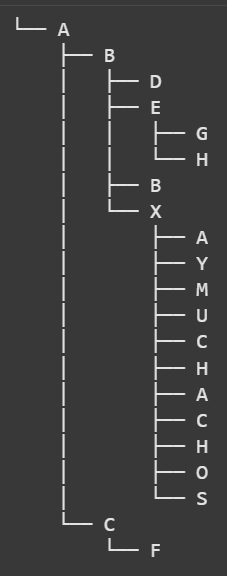

el resultado debería ser este:

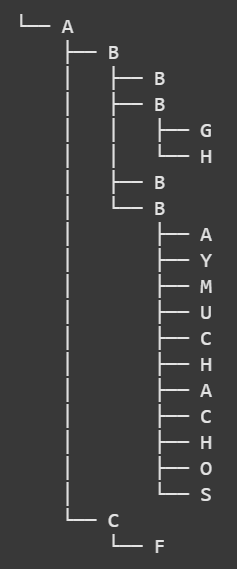

In [ ]:
#aquí es clave jugar con el orden de la recursión y la condición. Si esta condición se hace antes de la recursión -->
#Graaaaaave! Cambiaría todos los valores antes de ir a preguntar por su valor original
#pruébaselos en ambas vías para que ellos vean

def e1(current: GeneralNode, V: Any) -> None:
  for child in current.children:
    e1(child, V)
  if(current.value == V):
    for i in range(len(current.children)):
      current.children[i].value = V

tree = GeneralTree()
tree.insert(None, "A")   # raíz
tree.insert("A", "B")
tree.insert("A", "C")
tree.insert("B", "D")
tree.insert("B", "E")
tree.insert("C", "F")
tree.insert("E", "G")
tree.insert("E", "H")
tree.insert("B", "B")
tree.insert("B", "X")
tree.root.children[0].children[3].children.extend(list(map(GeneralNode, list("AYMUCHACHOS"))))
tree.insert("S", "B")
tree.root.children[0].children[3].children[-1].children[0].children.extend(list(map(GeneralNode, list("NOMEHAGANESTO"))))
print(tree)
e1(tree.root, "B")
print(tree)

# Ejercicio 2

* Dado un árbol general y un valor V, elimine todos los nodos cuyo valor sea V. Recuerde que cuando elimina un nodo, su descendencia se le asigna al padre. Supuesto: no se puede eliminar la raíz.

In [ ]:
#Aquí es importante explicar por qué no se puede parar apenas se encuentra
#un nodo a eliminar. Ellos ya han hecho varios donde con el primero que
#encuentran, paran y se devuelven.

def e2(current: GeneralNode, V: Any) -> None:
  for child in current.children:
    if(child.value == V):
      current.children.extend(child.children)
      current.children.remove(child)
    e2(child, V)

tree = GeneralTree()
tree.insert(None, "A")   # raíz
tree.insert("A", "B")
tree.insert("A", "C")
tree.insert("B", "D")
tree.insert("B", "E")
tree.insert("C", "F")
tree.insert("E", "G")
tree.insert("E", "H")
tree.insert("B", "B")
tree.insert("B", "X")
print(tree)
e2(tree.root, "G")
print(tree)

# Ejercicio 3

* Dado un árbol binario lleno de enteros y un valor V, devuelva todas las subramas cuya sumatoria sea V.

In [ ]:
#Aquí es importante explicarles que usualmente vale la pena separar la solución
#en varias funciones para mejorar la claridad. Además es importante hacer hincapié
#en la consistencia de los retornos, es decir, si digo que retorno un tipo de dato,
#lo debo cumplir en todos los flujos.
def sum_(current: BinaryNode, V: int, current_sum: List[int]) -> List[int]:
  if(current is None): return []
  if(current.value <= V):
    current_sum.append(current.value)
    if(sum(current_sum) == V):
      return current_sum
    return sum_(current.left, V, current_sum[:]) + sum_(current.right, V, current_sum[:])
  else: #matamos el flujo apenas nos pasemos del conteo
    return []

def e3(current: BinaryNode, V: int, answers: List[List[int]] = []) -> List[int]:
  if(current is None):
    return []

  result = sum_(current, V, [])
  if(result != []):
    answers.append(result)

  e3(current.left, V, answers)
  e3(current.right, V, answers)
  return answers


tree = BinaryTree()
tree.insert_by_level([1, 2, 3, None, 2, 6, None, 5,1,2,3,4,5,6,7,8,9]) #inserción por niveles
tree.insert(5,10) #inserción específica
tree.print()
print(e3(tree.root, 20))